In [1]:
import pandas as pd
import os 

In [2]:
sales = pd.read_csv("../data/raw/sales.csv")
inventory = pd.read_csv("../data/raw/inventory.csv")
products = pd.read_csv("../data/raw/products.csv")
stores = pd.read_csv("../data/raw/stores.csv")

In [3]:
sales.head()

,Sale_ID,Date,Store_ID,Product_ID,Units
0,1,2017-01-01,24,4,1
1,2,2017-01-01,28,1,1
2,3,2017-01-01,6,8,1
3,4,2017-01-01,48,7,1
4,5,2017-01-01,44,18,1


In [4]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829262 entries, 0 to 829261
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Sale_ID     829262 non-null  int64 
 1   Date        829262 non-null  object
 2   Store_ID    829262 non-null  int64 
 3   Product_ID  829262 non-null  int64 
 4   Units       829262 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 31.6+ MB


In [5]:
sales.columns

Index(['Sale_ID', 'Date', 'Store_ID', 'Product_ID', 'Units'], dtype='object')

In [6]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1593 entries, 0 to 1592
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Store_ID       1593 non-null   int64
 1   Product_ID     1593 non-null   int64
 2   Stock_On_Hand  1593 non-null   int64
dtypes: int64(3)
memory usage: 37.5 KB


In [7]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Product_ID        35 non-null     int64 
 1   Product_Name      35 non-null     object
 2   Product_Category  35 non-null     object
 3   Product_Cost      35 non-null     object
 4   Product_Price     35 non-null     object
dtypes: int64(1), object(4)
memory usage: 1.5+ KB


In [8]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Store_ID         50 non-null     int64 
 1   Store_Name       50 non-null     object
 2   Store_City       50 non-null     object
 3   Store_Location   50 non-null     object
 4   Store_Open_Date  50 non-null     object
dtypes: int64(1), object(4)
memory usage: 2.1+ KB


In [9]:
print("SALES")
print (sales.isnull().sum())

print("\nINVENTORY")
print(sales.isnull().sum())

print("\nPRODUCTS")
print(products.isnull().sum())

print("\nSTORES")
print(sales.isnull().sum())

SALES
Sale_ID       0
Date          0
Store_ID      0
Product_ID    0
Units         0
dtype: int64

INVENTORY
Sale_ID       0
Date          0
Store_ID      0
Product_ID    0
Units         0
dtype: int64

PRODUCTS
Product_ID          0
Product_Name        0
Product_Category    0
Product_Cost        0
Product_Price       0
dtype: int64

STORES
Sale_ID       0
Date          0
Store_ID      0
Product_ID    0
Units         0
dtype: int64


In [10]:
print("Sales duplicates:", sales.duplicated().sum())
print("Products duplicates:", products.duplicated().sum())
print("Stores duplicates:", stores.duplicated().sum())
print("Inventory duplicates:", inventory.duplicated().sum())

Sales duplicates: 0
Products duplicates: 0
Stores duplicates: 0
Inventory duplicates: 0


In [11]:
print("SALES")
print(sales.columns.tolist()) 
print("PRODUCTS")
print(products.columns.tolist())
print("STORES")
print(stores.columns.tolist())
print("INVENTORY")
print(inventory.columns.tolist())

SALES
['Sale_ID', 'Date', 'Store_ID', 'Product_ID', 'Units']
PRODUCTS
['Product_ID', 'Product_Name', 'Product_Category', 'Product_Cost', 'Product_Price']
STORES
['Store_ID', 'Store_Name', 'Store_City', 'Store_Location', 'Store_Open_Date']
INVENTORY
['Store_ID', 'Product_ID', 'Stock_On_Hand']


In [12]:
print("Sales → Products:", 
      sales["Product_ID"].isin(products["Product_ID"]).sum(), 
      "of", len(sales))
print("Sales → Stores:", 
      sales["Store_ID"].isin(stores["Store_ID"]).sum(), 
      "of", len(sales))

print("Inventory → Products:", 
      inventory["Product_ID"].isin(products["Product_ID"]).sum(), 
      "of", len(inventory))

print("Inventory → Stores:", 
      inventory["Store_ID"].isin(stores["Store_ID"]).sum(), 
      "of", len(inventory))

Sales → Products: 829262 of 829262
Sales → Stores: 829262 of 829262
Inventory → Products: 1593 of 1593
Inventory → Stores: 1593 of 1593


In [13]:
print("SALES UNITS")
print(sales["Units"].describe())

print("\n PRODUCTS COST AND PRICE")
print(products[["Product_Cost", "Product_Price"]].describe())

print("\nINVENTORY STOCK")
print(inventory["Stock_On_Hand"].describe())

SALES UNITS
count    829262.000000
mean          1.315103
std           0.830701
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          30.000000
Name: Units, dtype: float64

 PRODUCTS COST AND PRICE
       Product_Cost Product_Price
count            35            35
unique           16            18
top          $3.99        $19.99 
freq              5             5

INVENTORY STOCK
count    1593.000000
mean       18.670433
std        18.997652
min         0.000000
25%         6.000000
50%        13.000000
75%        24.000000
max       139.000000
Name: Stock_On_Hand, dtype: float64


In [14]:
print(products[["Product_Cost","Product_Price"]].head(10))

  Product_Cost Product_Price
0       $9.99        $15.99 
1       $9.99        $12.99 
2       $1.99         $3.99 
3       $9.99        $12.99 
4       $7.99         $9.99 
5       $6.99        $14.99 
6      $11.99        $15.99 
7       $3.99         $6.99 
8       $9.99        $10.99 
9      $10.99        $14.99 


In [15]:
print(products[["Product_Cost","Product_Price"]].dtypes)

Product_Cost     object
Product_Price    object
dtype: object


In [16]:
products["Product_Cost"] = products["Product_Cost"].str.replace("$","").astype(float)
products["Product_Price"] = products["Product_Price"].str.replace("$","").astype(float)

In [17]:
products[["Product_Cost", "Product_Price"]].head()

,Product_Cost,Product_Price
0,9.99,15.99
1,9.99,12.99
2,1.99,3.99
3,9.99,12.99
4,7.99,9.99


In [18]:
products[["Product_Cost", "Product_Price"]].dtypes

Product_Cost     float64
Product_Price    float64
dtype: object

In [19]:
products[["Product_Cost", "Product_Price"]].describe()

,Product_Cost,Product_Price
count,35.000000,35.000000
mean,10.247143,14.761429
std,6.563459,7.491508
min,1.990000,2.990000
25%,5.490000,9.990000
50%,9.990000,12.990000
75%,12.990000,19.990000
max,34.990000,39.990000


In [20]:
products["Product_Price"] < products["Product_Cost"]

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
dtype: bool

In [21]:
(products["Product_Price"] < products["Product_Cost"]).sum()

np.int64(0)

In [22]:
print(sales["Date"].head())

0    2017-01-01
1    2017-01-01
2    2017-01-01
3    2017-01-01
4    2017-01-01
Name: Date, dtype: object


In [23]:
print(sales["Date"].dtype)

object


In [24]:
sales["Date"] = pd.to_datetime(sales["Date"])

In [25]:
print(sales["Date"].dtype)

datetime64[ns]


In [26]:
stores["Store_Open_Date"] = pd.to_datetime(stores["Store_Open_Date"])
print(stores["Store_Open_Date"].dtype)

datetime64[ns]


In [27]:
print("Sales Start:",sales["Date"].min())
print("Sales end:", sales["Date"].max())

Sales Start: 2017-01-01 00:00:00
Sales end: 2018-09-30 00:00:00


In [28]:
print("Store data start:", stores["Store_Open_Date"].min())
print("Store data end:", stores["Store_Open_Date"].max())

Store data start: 1992-09-18 00:00:00
Store data end: 2016-05-18 00:00:00


In [29]:
sales["Year"] = sales["Date"].dt.year

sales["Year"].value_counts().sort_index()


Year
2017    420845
2018    408417
Name: count, dtype: int64

In [30]:
yearly_units = sales.groupby("Year")["Units"].sum()

yearly_units

Year
2017    549492
2018    541073
Name: Units, dtype: int64

In [31]:
yearly_units.pct_change() * 100


Year
2017         NaN
2018   -1.532142
Name: Units, dtype: float64

In [32]:
yearly_units

Year
2017    549492
2018    541073
Name: Units, dtype: int64

In [33]:
avg_units = sales.groupby("Year")["Units"].mean()

avg_units

Year
2017    1.305687
2018    1.324805
Name: Units, dtype: float64

In [34]:
monthly_units = sales.groupby(
    sales["Date"].dt.to_period("M")
)["Units"].sum()

monthly_units

Date
2017-01    38009
2017-02    36935
2017-03    39981
2017-04    47102
2017-05    46910
2017-06    47178
2017-07    46177
2017-08    39927
2017-09    42196
2017-10    47861
2017-11    51185
2017-12    66031
2018-01    56478
2018-02    54581
2018-03    69336
2018-04    65593
2018-05    63851
2018-06    64275
2018-07    63614
2018-08    51193
2018-09    52152
Freq: M, Name: Units, dtype: int64

<Axes: xlabel='Date'>

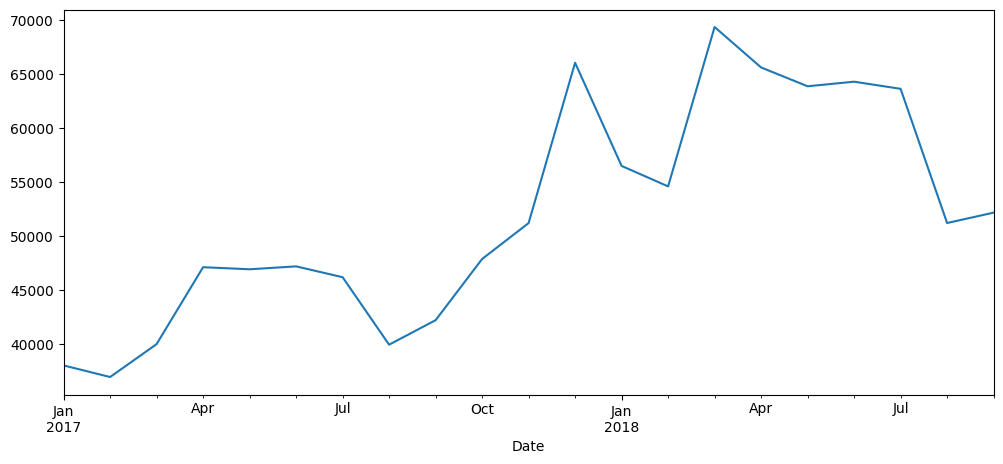

In [35]:
monthly_units.plot(figsize=(12, 5))

In [36]:
print(sales["Date"].min())
print(sales["Date"].max())

2017-01-01 00:00:00
2018-09-30 00:00:00


In [37]:
sales_9m = sales[sales["Date"].dt.month <= 9]

units_9m = sales_9m.groupby("Year")["Units"].sum()

units_9m

Year
2017    384415
2018    541073
Name: Units, dtype: int64

In [38]:
sales_products = sales.merge(
    products,
    on="Product_ID",
    how="left"
)

In [39]:
category_units = sales_products.groupby("Product_Category")["Units"].sum().sort_values(ascending=False)

category_units

Product_Category
Art & Crafts         325574
Toys                 267200
Games                194673
Sports & Outdoors    169043
Electronics          134075
Name: Units, dtype: int64

In [40]:
sales_products["Revenue"] = (
    sales_products["Units"] * sales_products["Product_Price"]
)

sales_products["Cost"] = (
    sales_products["Units"] * sales_products["Product_Cost"]
)

sales_products["Profit"] = (
    sales_products["Revenue"] - sales_products["Cost"]
)

In [41]:
category_performance = sales_products.groupby("Product_Category")[
    ["Units", "Revenue", "Profit"]
].sum().sort_values("Revenue", ascending=False)

category_performance

,Units,Revenue,Profit
Product_Category,,,
Toys,267200,5093241.00,1079527.0
Art & Crafts,325574,2705364.26,753354.0
Electronics,134075,2246771.25,1001437.0
Games,194673,2226836.27,673993.0
Sports & Outdoors,169043,2172359.57,505718.0


In [42]:
category_performance["Profit_Margin"] = (
    category_performance["Profit"] /
    category_performance["Revenue"] * 100
)

category_performance.sort_values("Profit_Margin", ascending=False)

,Units,Revenue,Profit,Profit_Margin
Product_Category,,,,
Electronics,134075,2246771.25,1001437.0,44.572272
Games,194673,2226836.27,673993.0,30.266841
Art & Crafts,325574,2705364.26,753354.0,27.846675
Sports & Outdoors,169043,2172359.57,505718.0,23.279664
Toys,267200,5093241.00,1079527.0,21.195286


In [43]:
inventory_products = inventory.merge(
    products,
    on="Product_ID",
    how="left"
)

In [44]:
inventory_category = inventory_products.groupby("Product_Category")[
    "Stock_On_Hand"
].sum().sort_values(ascending=False)

inventory_category

Product_Category
Art & Crafts         8635
Toys                 7553
Games                6155
Sports & Outdoors    4981
Electronics          2418
Name: Stock_On_Hand, dtype: int64

In [45]:
monthly_category_demand = sales_products.groupby(
    [sales_products["Date"].dt.to_period("M"), "Product_Category"]
)["Units"].sum()

avg_monthly_category_demand = monthly_category_demand.groupby(
    "Product_Category"
).mean()

avg_monthly_category_demand

Product_Category
Art & Crafts         15503.523810
Electronics           6384.523810
Games                 9270.142857
Sports & Outdoors     8049.666667
Toys                 12723.809524
Name: Units, dtype: float64

In [46]:
inventory_category = inventory_products.groupby(
    "Product_Category"
)["Stock_On_Hand"].sum()

category_stock_coverage = (
    inventory_category / avg_monthly_category_demand
).sort_values(ascending=False)

category_stock_coverage

Product_Category
Games                0.663960
Sports & Outdoors    0.618783
Toys                 0.593612
Art & Crafts         0.556970
Electronics          0.378728
dtype: float64

In [47]:
product_demand = sales_products.groupby("Product_ID")["Units"].sum()

product_inventory = inventory.groupby("Product_ID")["Stock_On_Hand"].sum()

product_analysis = products[
    ["Product_ID", "Product_Name", "Product_Category", "Product_Price"]
].copy()

product_analysis["Total_Units_Sold"] = (
    product_analysis["Product_ID"].map(product_demand)
)

product_analysis["Stock_On_Hand"] = (
    product_analysis["Product_ID"].map(product_inventory)
)

product_analysis.head()

,Product_ID,Product_Name,Product_Category,Product_Price,Total_Units_Sold,Stock_On_Hand
0,1,Action Figure,Toys,15.99,57958,614
1,2,Animal Figures,Toys,12.99,39089,835
2,3,Barrel O' Slime,Art & Crafts,3.99,91663,1282
3,4,Chutes & Ladders,Games,12.99,3829,255
4,5,Classic Dominoes,Games,9.99,4471,241


In [48]:
product_analysis["Avg_Monthly_Demand"] = (
    product_analysis["Total_Units_Sold"] / 21
)

In [49]:
product_analysis["Stock_Coverage_Months"] = (
    product_analysis["Stock_On_Hand"] /
    product_analysis["Avg_Monthly_Demand"]
)

In [50]:
product_analysis.sort_values(
    "Stock_Coverage_Months"
).head(10)

,Product_ID,Product_Name,Product_Category,Product_Price,Total_Units_Sold,Stock_On_Hand,Avg_Monthly_Demand,Stock_Coverage_Months
0,1,Action Figure,Toys,15.99,57958,614,2759.904762,0.222471
5,6,Colorbuds,Electronics,14.99,104368,1159,4969.904762,0.233204
15,16,Jenga,Games,9.99,13054,181,621.619048,0.291175
2,3,Barrel O' Slime,Art & Crafts,3.99,91663,1282,4364.904762,0.293706
30,31,Splash Balls,Sports & Outdoors,8.99,60248,893,2868.952381,0.311263
14,15,Hot Wheels 5-Pack,Toys,5.99,22659,376,1079.000000,0.348471
8,9,Dino Egg,Toys,10.99,38236,649,1820.761905,0.356444
17,18,Lego Bricks,Toys,39.99,59737,1118,2844.619048,0.393023
24,25,PlayDoh Can,Art & Crafts,2.99,103128,2129,4910.857143,0.433529
13,14,Glass Marbles,Games,10.99,37518,795,1786.571429,0.444986


In [52]:
stockouts = inventory[inventory["Stock_On_Hand"] == 0]
print("Total stockout records:", len(stockouts))

Total stockout records: 77


In [54]:
stockouts_by_product = stockouts.groupby("Product_ID").size().sort_values(ascending = False)
stockouts_by_product.head(10)

Product_ID
28    13
15    12
11     7
12     6
21     6
9      6
1      5
2      3
33     3
29     3
dtype: int64

In [61]:
stockout_products = stockouts.merge(
    products[["Product_ID","Product_Name","Product_Category"]],
    on = "Product_ID",
    how = "left"
)

stockout_products.groupby(
    ["Product_ID", "Product_Name","Product_Category"]
).size().sort_values(ascending=False).head(10)

Product_ID  Product_Name        Product_Category 
28          Playfoam            Art & Crafts         13
15          Hot Wheels 5-Pack   Toys                 12
11          Etch A Sketch       Art & Crafts          7
12          Foam Disk Launcher  Sports & Outdoors     6
21          Mini Ping Pong Set  Sports & Outdoors     6
9           Dino Egg            Toys                  6
1           Action Figure       Toys                  5
2           Animal Figures      Toys                  3
33          Teddy Bear          Toys                  3
29          Plush Pony          Toys                  3
dtype: int64

In [62]:
stockout_summary = stockout_products.groupby(
    ["Product_ID", "Product_Name", "Product_Category"]
).size().reset_index(name="Stockout_Stores")

stockout_summary = stockout_summary.merge(
    product_analysis[
        ["Product_ID","Total_Units_Sold","Stock_On_Hand", "Stock_Coverage_Months"]
    ],
    on = "Product_ID",
    how = "left"
)

stockout_summary.sort_values(
    ["Stockout_Stores","Total_Units_Sold"],
    ascending= False
).head(10)

,Product_ID,Product_Name,Product_Category,Stockout_Stores,Total_Units_Sold,Stock_On_Hand,Stock_Coverage_Months
14,28,Playfoam,Art & Crafts,13,4158,357,1.803030
10,15,Hot Wheels 5-Pack,Toys,12,22659,376,0.348471
6,11,Etch A Sketch,Art & Crafts,7,12168,402,0.693787
5,9,Dino Egg,Toys,6,38236,649,0.356444
12,21,Mini Ping Pong Set,Sports & Outdoors,6,33604,974,0.608678
7,12,Foam Disk Launcher,Sports & Outdoors,6,7620,379,1.044488
0,1,Action Figure,Toys,5,57958,614,0.222471
1,2,Animal Figures,Toys,3,39089,835,0.448592
18,33,Teddy Bear,Toys,3,6416,483,1.580892
15,29,Plush Pony,Toys,3,5488,497,1.901786


In [63]:
playfoam_inventory = inventory[
    inventory["Product_ID"] == 28
]
playfoam_inventory.merge(
    stores[["Store_ID","Store_Name","Store_City"]],
    on = "Store_ID",
    how = "left"
).sort_values("Stock_On_Hand")

,Store_ID,Product_ID,Stock_On_Hand,Store_Name,Store_City
6,7,28,0,Maven Toys Monterrey 2,Monterrey
4,5,28,0,Maven Toys La Paz 1,La Paz
12,13,28,0,Maven Toys Mexicali 2,Mexicali
15,16,28,0,Maven Toys San Luis Potosi 1,San Luis Potosi
21,22,28,0,Maven Toys Guanajuato 2,Guanajuato
23,24,28,0,Maven Toys Aguascalientes 1,Aguascalientes
17,18,28,0,Maven Toys Merida 1,Merida
38,39,28,0,Maven Toys Xalapa 2,Xalapa
40,41,28,0,Maven Toys Hermosillo 2,Hermosillo
41,42,28,0,Maven Toys Hermosillo 3,Hermosillo


In [64]:
playfoam_inventory["Stock_On_Hand"].describe()

count    49.000000
mean      7.285714
std       9.365273
min       0.000000
25%       0.000000
50%       4.000000
75%      10.000000
max      48.000000
Name: Stock_On_Hand, dtype: float64

In [65]:
playfoam_inventory["Stock_On_Hand"].value_counts().sort_index()

Stock_On_Hand
0     13
1      3
2      3
3      4
4      3
5      2
6      2
7      2
8      1
9      1
10     5
11     1
13     1
16     1
19     1
20     2
22     1
26     2
48     1
Name: count, dtype: int64

In [66]:
store_stockouts = inventory[inventory["Stock_On_Hand"] ==0].groupby(
    "Store_ID"
).size().sort_values(ascending=False)
store_stockouts.head(10)


Store_ID
5     5
13    5
41    4
8     4
24    4
44    3
22    3
2     3
1     3
19    3
dtype: int64

In [67]:
store_stockout_summary = store_stockouts.reset_index(
    name="Out_of_Stock_Products"
).merge(
    stores[["Store_ID", "Store_Name", "Store_City"]],
    on="Store_ID",
    how="left"
)

store_stockout_summary

,Store_ID,Out_of_Stock_Products,Store_Name,Store_City
0,5,5,Maven Toys La Paz 1,La Paz
1,13,5,Maven Toys Mexicali 2,Mexicali
2,41,4,Maven Toys Hermosillo 2,Hermosillo
3,8,4,Maven Toys Pachuca 1,Pachuca
4,24,4,Maven Toys Aguascalientes 1,Aguascalientes
5,44,3,Maven Toys Puebla 3,Puebla
6,22,3,Maven Toys Guanajuato 2,Guanajuato
7,2,3,Maven Toys Monterrey 1,Monterrey
8,1,3,Maven Toys Guadalajara 1,Guadalajara
9,19,3,Maven Toys Puebla 1,Puebla


In [68]:
store_performance = sales_products.groupby(
    "Store_ID"
)[["Units","Revenue","Profit"]].sum()

store_performance = store_performance.merge(
    stores[["Store_ID", "Store_Name", "Store_City"]],
    on = "Store_ID",
    how = "left"
)
store_performance.sort_values(
    "Revenue", ascending =  False
).head(10)

,Store_ID,Units,Revenue,Profit,Store_Name,Store_City
30,31,42757,554553.43,169856.0,Maven Toys Ciudad de Mexico 2,Cuidad de Mexico
29,30,31609,449354.91,121571.0,Maven Toys Guadalajara 3,Guadalajara
8,9,33479,433556.21,111296.0,Maven Toys Ciudad de Mexico 1,Cuidad de Mexico
16,17,32668,411157.32,104612.0,Maven Toys Toluca 1,Toluca
6,7,28318,372998.82,106783.0,Maven Toys Monterrey 2,Monterrey
45,46,24136,348466.64,102178.0,Maven Toys Guadalajara 4,Guadalajara
41,42,23236,344846.64,98825.0,Maven Toys Hermosillo 3,Hermosillo
38,39,25296,344307.04,88637.0,Maven Toys Xalapa 2,Xalapa
36,37,26634,337424.66,94021.0,Maven Toys Ciudad de Mexico 3,Cuidad de Mexico
3,4,24010,330408.90,94252.0,Maven Toys Saltillo 1,Saltillo


In [69]:
store_risk = store_performance.merge(
    store_stockout_summary,
    on=["Store_ID", "Store_Name", "Store_City"],
    how="left"
)

store_risk["Out_of_Stock_Products"] = (
    store_risk["Out_of_Stock_Products"].fillna(0)
)

store_risk.sort_values(
    ["Out_of_Stock_Products", "Revenue"],
    ascending=[False, False]
).head(15)

,Store_ID,Units,Revenue,Profit,Store_Name,Store_City,Out_of_Stock_Products
12,13,21557,292156.43,77842.0,Maven Toys Mexicali 2,Mexicali,5.0
4,5,16217,210897.83,57407.0,Maven Toys La Paz 1,La Paz,5.0
40,41,23498,323427.02,87995.0,Maven Toys Hermosillo 2,Hermosillo,4.0
23,24,17865,239997.35,68642.0,Maven Toys Aguascalientes 1,Aguascalientes,4.0
7,8,19185,237676.15,63989.0,Maven Toys Pachuca 1,Pachuca,4.0
38,39,25296,344307.04,88637.0,Maven Toys Xalapa 2,Xalapa,3.0
13,14,24740,313916.60,88002.0,Maven Toys Guanajuato 1,Guanajuato,3.0
21,22,21133,278926.67,79550.0,Maven Toys Guanajuato 2,Guanajuato,3.0
1,2,20886,277959.14,73985.0,Maven Toys Monterrey 1,Monterrey,3.0
43,44,19345,267559.55,78670.0,Maven Toys Puebla 3,Puebla,3.0


In [70]:
products.to_csv("../data/cleaned/products_cleaned.csv", index=False)
sales.to_csv("../data/cleaned/sales_cleaned.csv", index=False)
inventory.to_csv("../data/cleaned/inventory_cleaned.csv", index=False)
stores.to_csv("../data/cleaned/stores_cleaned.csv", index=False)

In [71]:
sales_clean_sql = sales[
    ["Sale_ID", "Date", "Store_ID", "Product_ID", "Units"]
]

sales_clean_sql.to_csv(
    "../data/cleaned/sales_for_sql.csv",
    index=False
)

In [72]:
pd.read_csv("../data/cleaned/sales_for_sql.csv").head()

,Sale_ID,Date,Store_ID,Product_ID,Units
0,1,2017-01-01,24,4,1
1,2,2017-01-01,28,1,1
2,3,2017-01-01,6,8,1
3,4,2017-01-01,48,7,1
4,5,2017-01-01,44,18,1
